# VMISS threshold tuning (v6) — by depth subgroup

Reuses the pipeline's per-variant VMISS summary (computed on the `07_sample_qc` genotype) and picks a
per-variant call-rate threshold per depth subgroup (15X / 30X) via the **Kneedle** elbow on the VMISS
cumulative distribution. All logic lives in `scripts/vmiss_tuning.py`; this notebook only calls it.
It **recommends** data-driven thresholds; it does not edit the variant-QC config.

In [1]:
import sys
sys.path.insert(0, '/LARGE0/gr10478/b37974/Pulmonary_Hypertension/cteph_agp3k.v6/tuning.vmiss/scripts')
import vmiss_tuning as vm

# Stream the summary once; build per-depth CDF + Kneedle knee (+ joint dp retention).
results = vm.analyze_depth()

[vmiss] subgroup N: {'15X': 3148, '30X': 421}  -> CDF bins: {'15X': 0.001, '30X': 0.005}
[vmiss] reading cteph_agp3k_v6_wgs_merged.sample_qc.variant_qc.variant_qc_summary.tsv (streaming, chunksize=2,000,000) ...
[vmiss] 15X: n=37,209,295  median=0.0260  knee VMISS=0.04 (retained 80.5%)
[vmiss] 30X: n=37,209,295  median=0.0100  knee VMISS=0.03 (retained 81.2%)
[vmiss] joint (dp): 15X<=0.04 & 30X<=0.03  retained 26,727,933 (71.8% of 37,209,295)


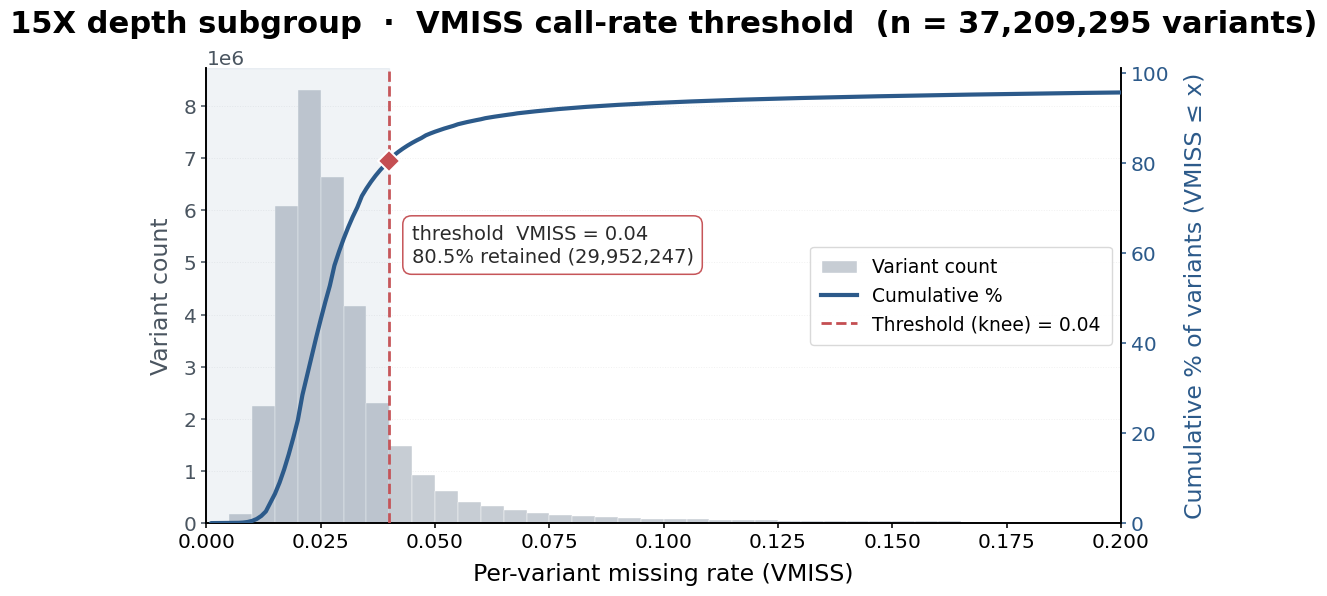

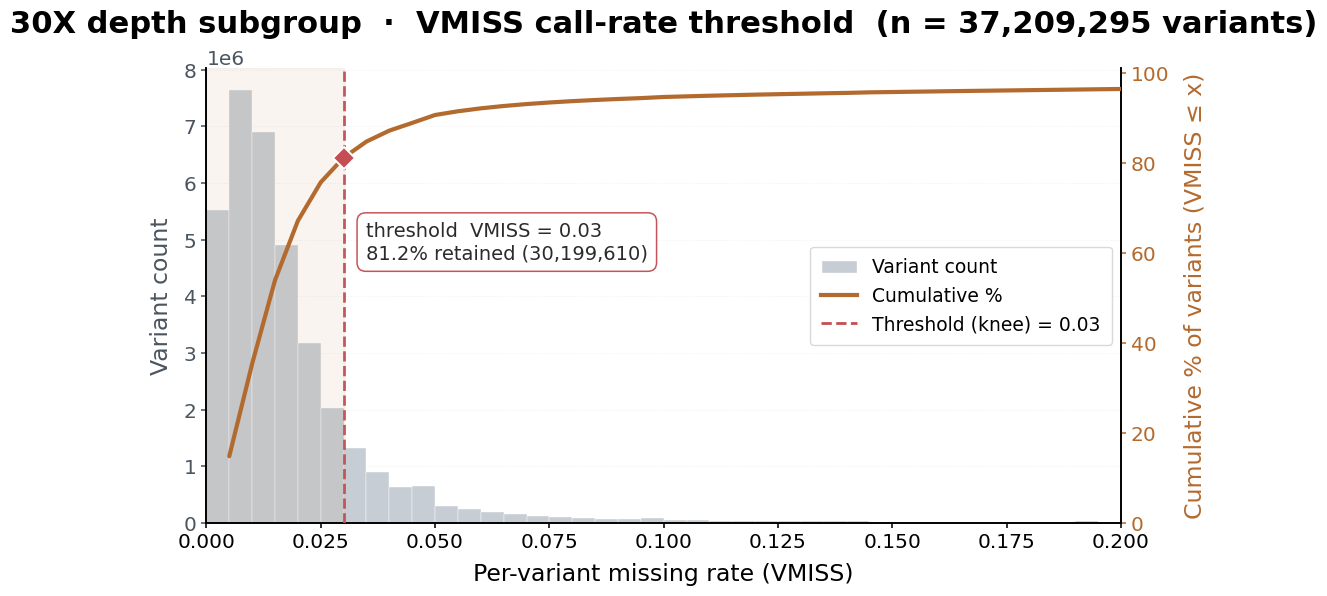

In [2]:
# One figure per depth subgroup: histogram (count) + cumulative % + Kneedle knee (vs current config).
_ = vm.plot_depth(results)

In [3]:
# Recommended VMISS per depth subgroup vs the current vqc_config_vmiss.json dp block.
import pandas as pd
with pd.option_context('display.max_rows', None, 'display.precision', 4):
    display(results['recommendations_df'])

,group,vmiss_col,total_variants,median_vmiss,mean_vmiss,recommended_vmiss,retained_pct,retained_n
0,15X,15X_VMISS,37209295,0.026,0.0515,0.04,80.50,29952247
1,30X,30X_VMISS,37209295,0.010,0.0356,0.03,81.16,30199610
2,joint (dp),15X<=0.04 & 30X<=0.03,37209295,NaN,NaN,NaN,71.83,26727933
